<a href="https://colab.research.google.com/github/jggoncalez/cardiovascular-diseases-AI/blob/main/cd_analise_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook do Dataset de Doenças Cardiovasculares

### Setup Inicial

In [22]:
url = "https://raw.githubusercontent.com/jggoncalez/cardiovascular-diseases-AI/main/data/Cardiovascular_Disease_Dataset.csv"

In [3]:
!git clone https://github.com/jggoncalez/cardiovascular-diseases-AI.git
%cd cardiovascular-diseases-AI
!pip install -r requirements.txt

Cloning into 'cardiovascular-diseases-AI'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 11 (delta 1), reused 8 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 17.25 KiB | 5.75 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/cardiovascular-diseases-AI
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 5.8 MB/s eta 0:00:00


In [28]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
import sklearn.model_selection as model_selection

#from catboost import CatBoostClassifier
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv(url)

In [20]:
data.head()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,Masculino,2,171,0,0,1,147,0,5.3,3,3,NaN
1,119250,40,Masculino,0,94,229,0,1,115,0,3.7,1,1,NaN
2,119372,49,Masculino,2,133,142,0,0,202,1,5.0,1,0,NaN
3,132514,43,Masculino,0,138,295,1,1,153,0,3.2,2,2,NaN
4,146211,31,Masculino,1,199,0,0,2,136,0,5.3,3,2,NaN


### Análise Exploratória de Dados

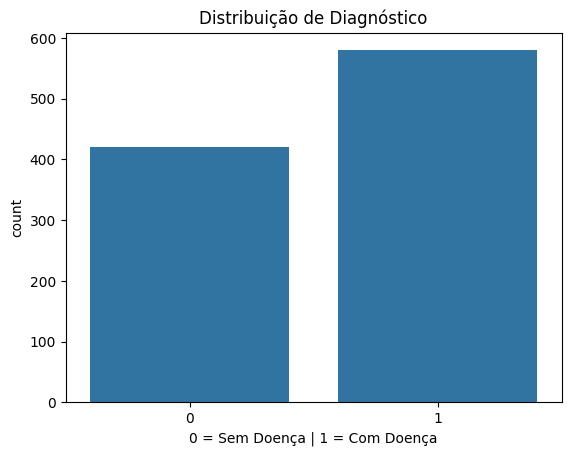

In [31]:
# Distribuição de target

sns.countplot(x='target', data=data)
plt.title('Distribuição de Diagnóstico')
plt.xlabel('0 = Sem Doença | 1 = Com Doença')
plt.show()

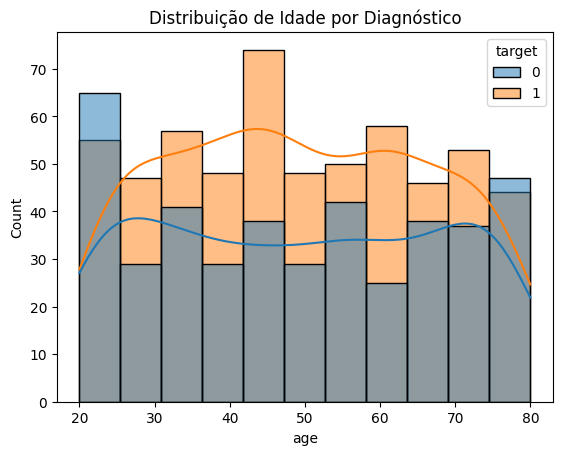

In [33]:
# Idade por diagnóstico

sns.histplot(data=data, x='age', hue='target', kde=True)
plt.title('Distribuição de Idade por Diagnóstico')
plt.show()

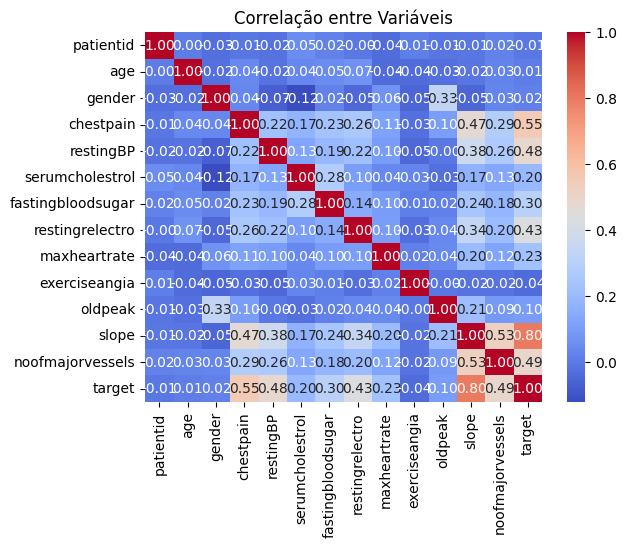

In [35]:
# Heatmap por correlação

sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlação entre Variáveis')
plt.show()

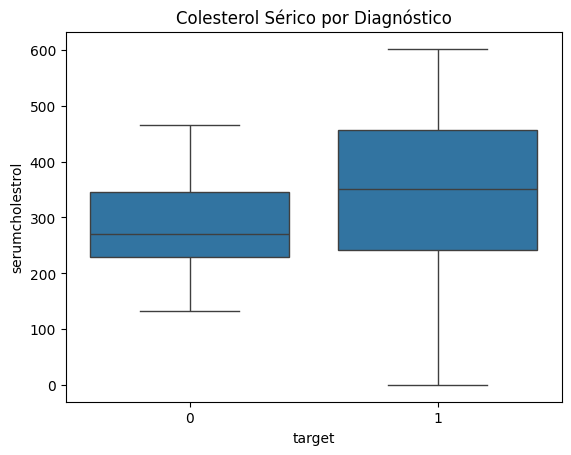

In [37]:
# Colesterol por diagnóstico

sns.boxplot(x='target', y='serumcholestrol', data=data)
plt.title('Colesterol Sérico por Diagnóstico')
plt.show()

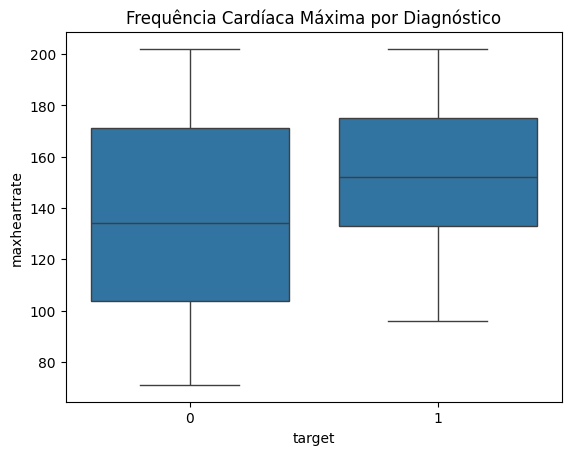

In [38]:
# Frequência Cardíaca Máxima

sns.boxplot(x='target', y='maxheartrate', data=data)
plt.title('Frequência Cardíaca Máxima por Diagnóstico')
plt.show()